<a href="https://colab.research.google.com/github/Student-NitinRaj/Data-Analysis-HUB-/blob/main/Healthcare_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("ajaypalsinghlo/world-happiness-report-2021")

100%|██████████| 55.2k/55.2k [00:00<00:00, 1.41MB/s]

Extracting files...


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
# The `path` variable is the directory where the dataset was downloaded.
# We need to construct the full path to the CSV file inside this directory.
# Assuming the main data file is named 'world-happiness-report-2021.csv'.
# You can use `print(os.listdir(path))` in a new cell to see all files in the directory if this filename is incorrect.
csv_file_name = 'world-happiness-report-2021.csv'
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)

In [5]:
df.head()

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


In [7]:
df.shape

(149, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                149 non-null    object 
 1   Regional indicator                          149 non-null    object 
 2   Ladder score                                149 non-null    float64
 3   Standard error of ladder score              149 non-null    float64
 4   upperwhisker                                149 non-null    float64
 5   lowerwhisker                                149 non-null    float64
 6   Logged GDP per capita                       149 non-null    float64
 7   Social support                              149 non-null    float64
 8   Healthy life expectancy                     149 non-null    float64
 9   Freedom to make life choices                149 non-null    float64
 10  Generosity    

In [10]:
df.describe().sum()

,0
Ladder score,182.612762
Standard error of ladder score,149.446753
upperwhisker,183.162336
lowerwhisker,181.988510
Logged GDP per capita,206.403810
Social support,153.862634
Healthy life expectancy,542.190842
Freedom to make life choices,153.655929
Generosity,149.306522
Perceptions of corruption,153.220676


In [11]:
df.isna().sum()

,0
Country name,0
Regional indicator,0
Ladder score,0
Standard error of ladder score,0
upperwhisker,0
lowerwhisker,0
Logged GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0


In [13]:
df.duplicated().sum()

np.int64(0)

<Axes: >

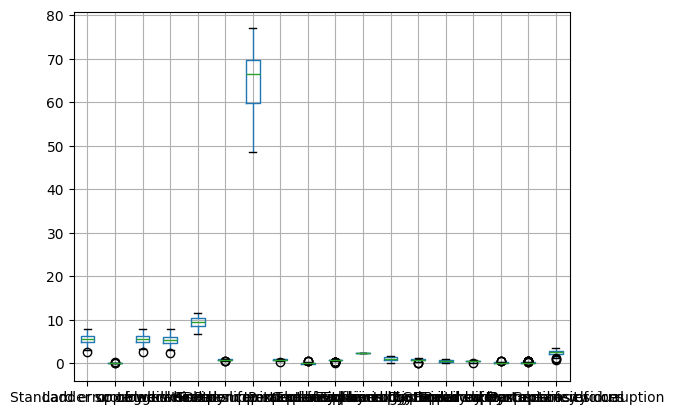

In [14]:
df.boxplot()

### Correlation Matrix
Let's examine the correlation between the numerical features to understand their relationships.

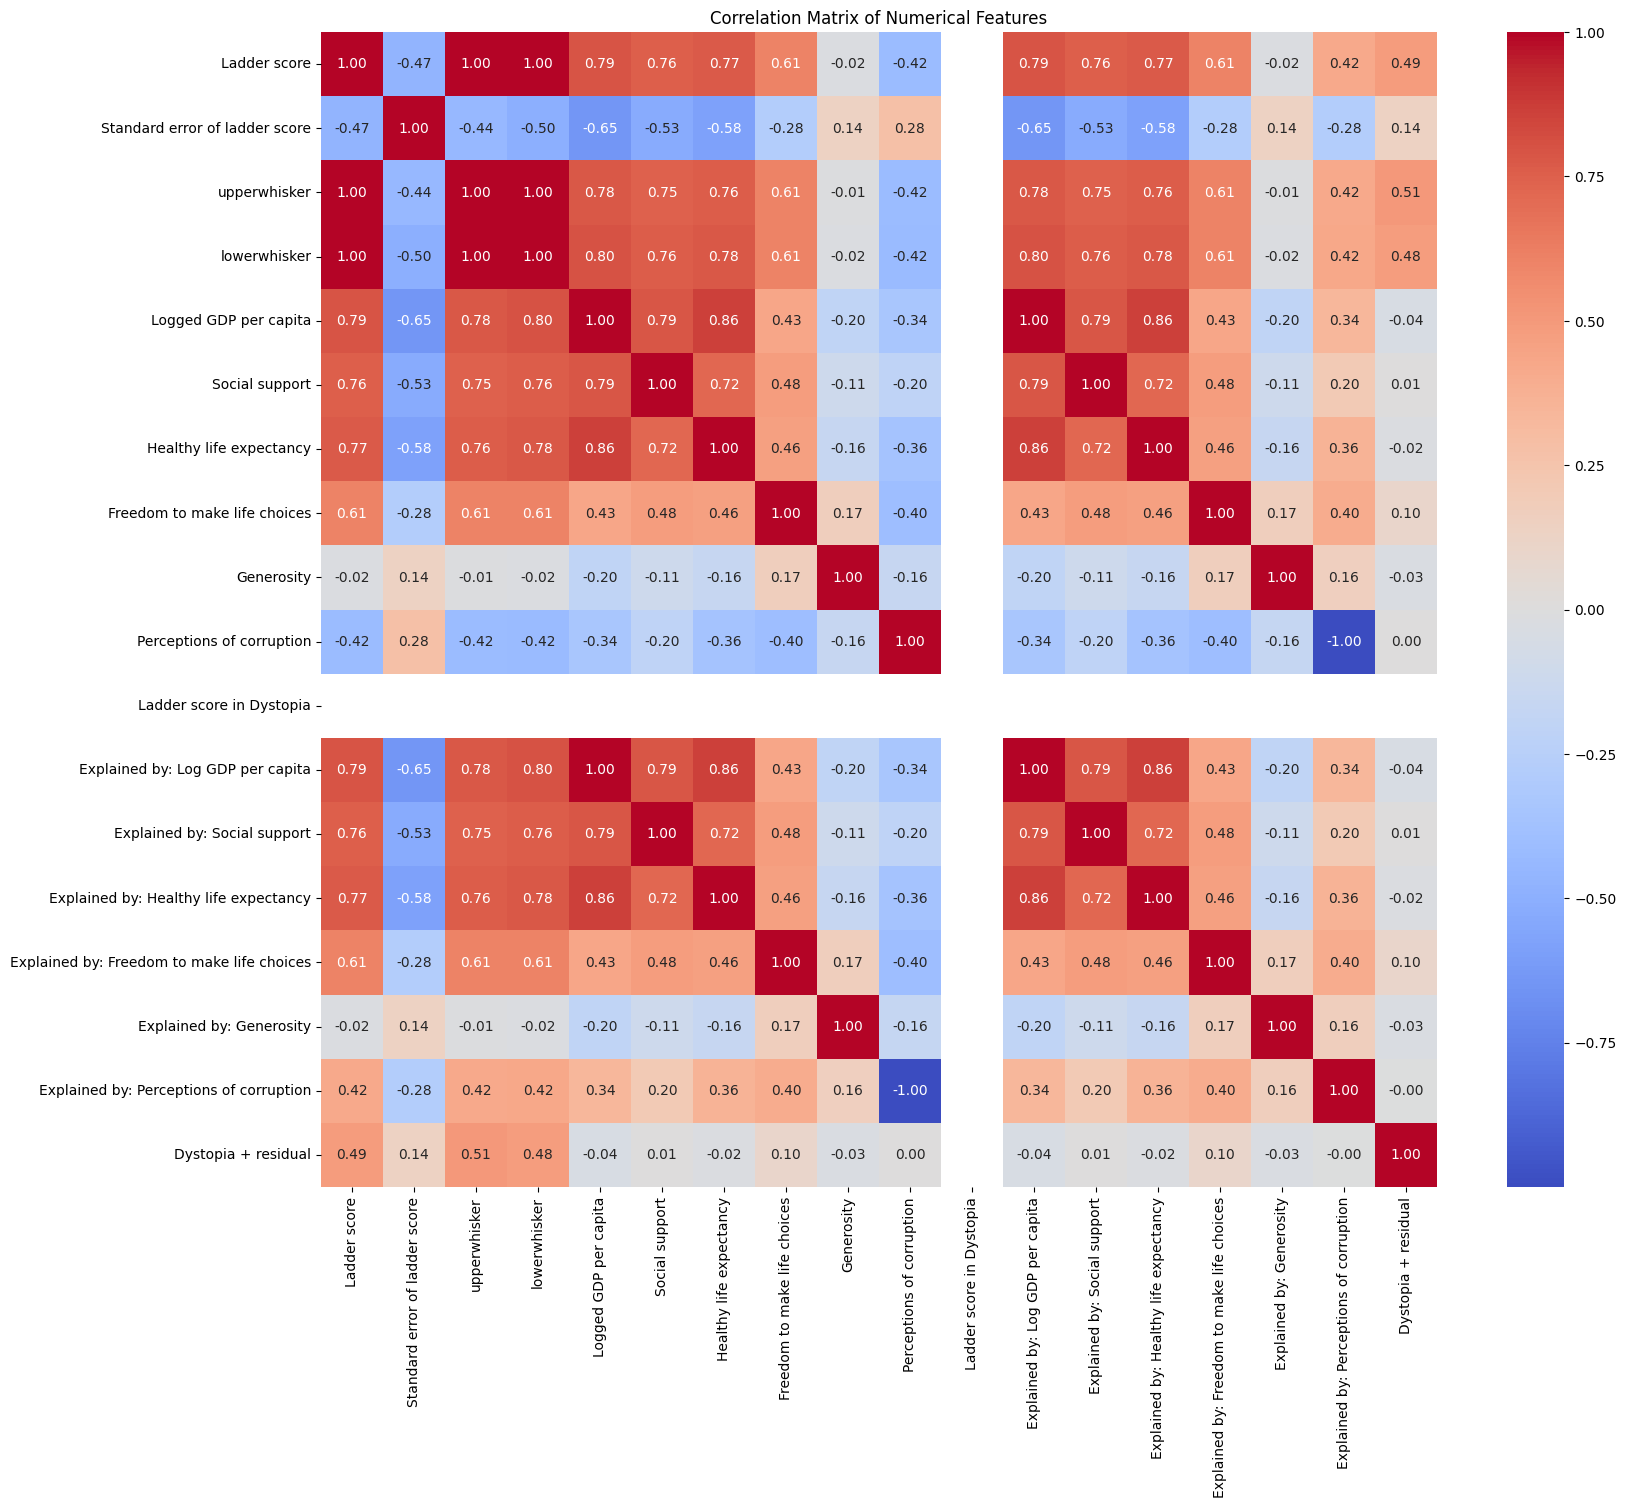

In [15]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Plot the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Distribution of Key Variables
Now, let's look at the distribution of the 'Ladder score' and 'Regional indicator' to get a better sense of their spread and composition.

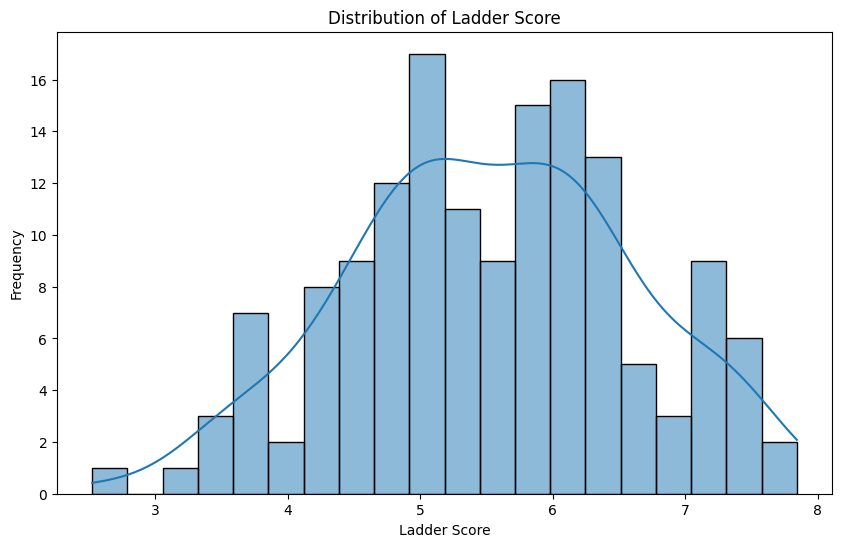

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Ladder score'], kde=True, bins=20)
plt.title('Distribution of Ladder Score')
plt.xlabel('Ladder Score')
plt.ylabel('Frequency')
plt.show()

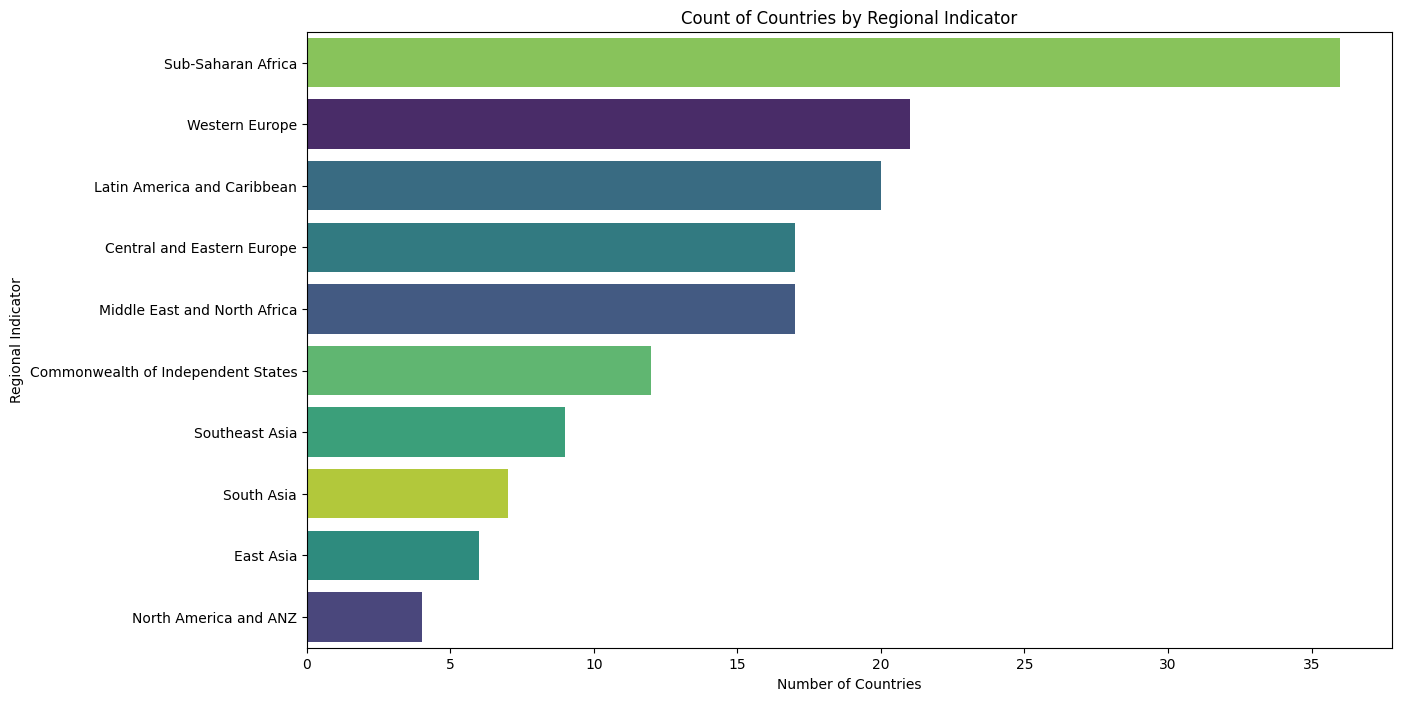

In [18]:
plt.figure(figsize=(14, 8))
sns.countplot(y=df['Regional indicator'], order=df['Regional indicator'].value_counts().index, palette='viridis', hue=df['Regional indicator'], legend=False)
plt.title('Count of Countries by Regional Indicator')
plt.xlabel('Number of Countries')
plt.ylabel('Regional Indicator')
plt.show()

### Ladder Score Distribution by Regional Indicator
Let's visualize how the 'Ladder score' varies across different 'Regional indicators' using a box plot. This will show us the median, quartiles, and potential outliers for each region's happiness score.

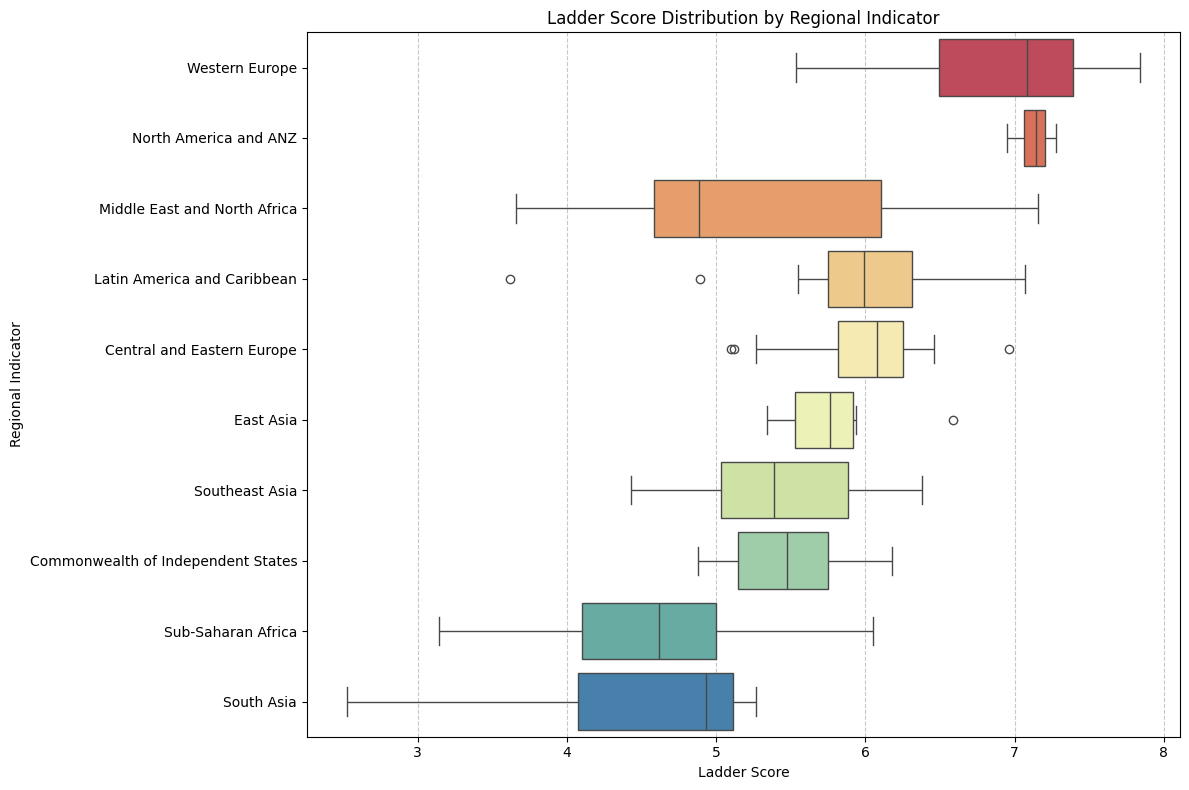

In [21]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='Ladder score', y='Regional indicator', data=df, palette='Spectral', hue='Regional indicator', legend=False)
plt.title('Ladder Score Distribution by Regional Indicator')
plt.xlabel('Ladder Score')
plt.ylabel('Regional Indicator')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top and Bottom 10 Happiest Countries
Let's identify and visualize the countries with the highest and lowest 'Ladder scores' to highlight the extremes in global happiness.

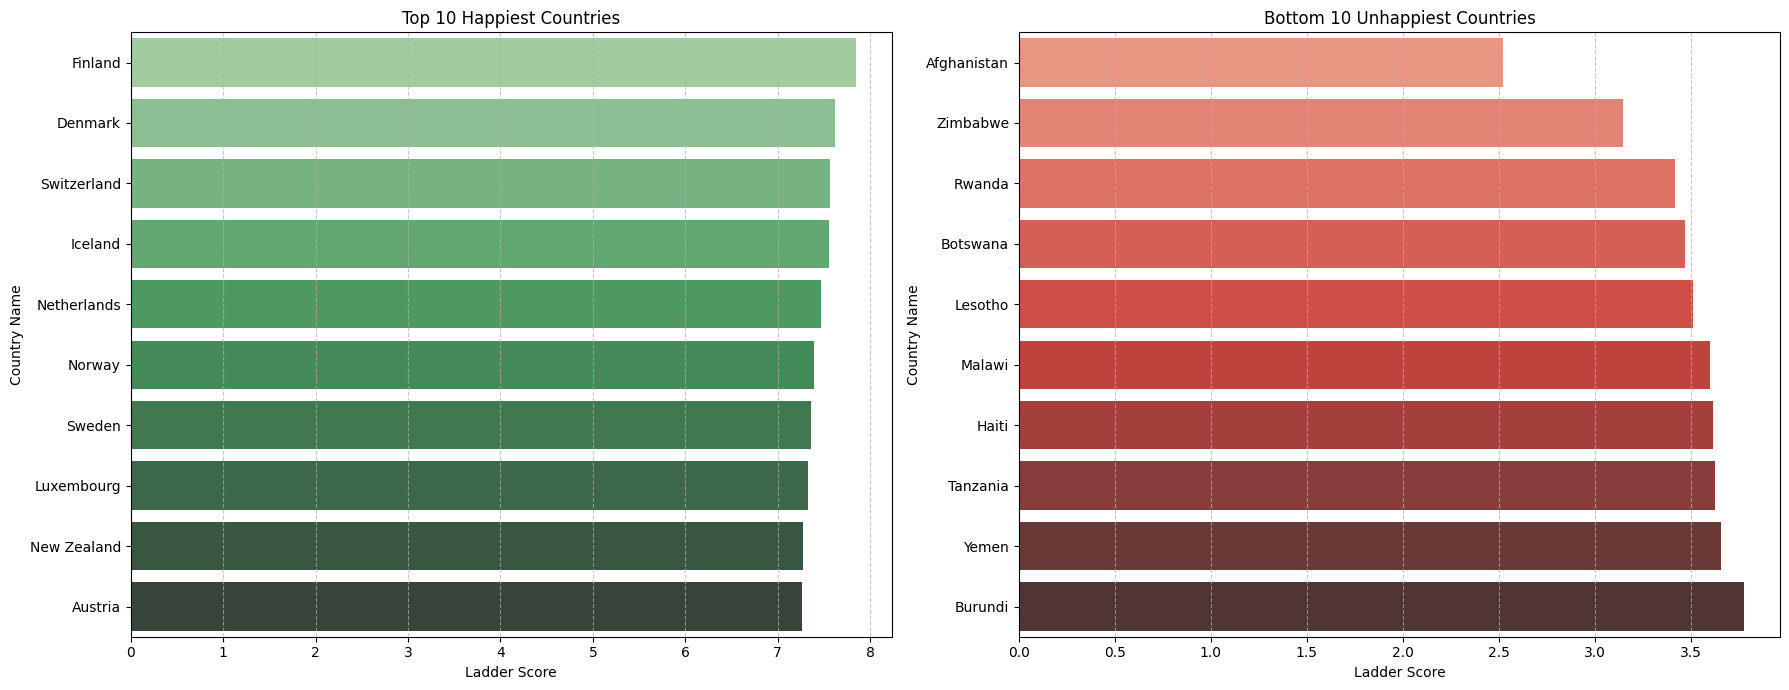

In [22]:
# Sort by Ladder score to get top and bottom countries
top_10_happiest = df.sort_values(by='Ladder score', ascending=False).head(10)
bottom_10_unhappiest = df.sort_values(by='Ladder score', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False) # Use sharey=False for independent y-axes

sns.barplot(ax=axes[0], x='Ladder score', y='Country name', data=top_10_happiest, palette='Greens_d', hue='Country name', legend=False)
axes[0].set_title('Top 10 Happiest Countries')
axes[0].set_xlabel('Ladder Score')
axes[0].set_ylabel('Country Name')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

sns.barplot(ax=axes[1], x='Ladder score', y='Country name', data=bottom_10_unhappiest, palette='Reds_d', hue='Country name', legend=False)
axes[1].set_title('Bottom 10 Unhappiest Countries')
axes[1].set_xlabel('Ladder Score')
axes[1].set_ylabel('Country Name')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Happiness vs. Economic Prosperity by Region
Let's visualize the relationship between 'Ladder score' and 'Logged GDP per capita', breaking it down by 'Regional indicator'. This can reveal interesting patterns about how economic factors contribute to happiness across different parts of the world.

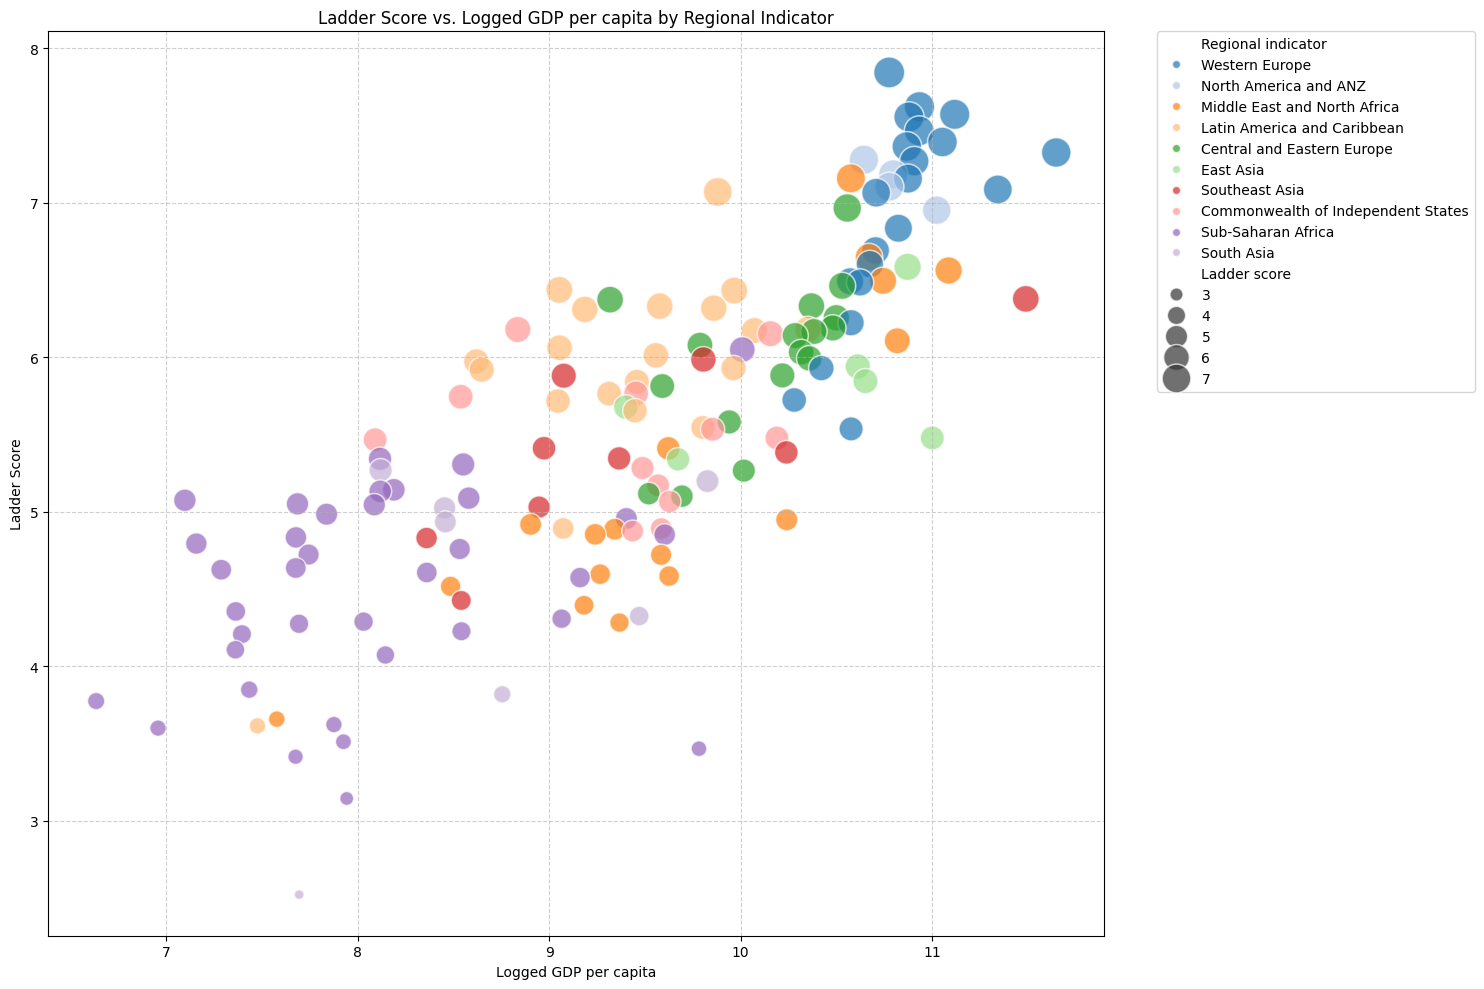

In [23]:
plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df,
    x='Logged GDP per capita',
    y='Ladder score',
    hue='Regional indicator',
    size='Ladder score', # Make marker size proportional to ladder score
    sizes=(50, 500), # Range for marker sizes
    alpha=0.7,
    palette='tab20'
)
plt.title('Ladder Score vs. Logged GDP per capita by Regional Indicator')
plt.xlabel('Logged GDP per capita')
plt.ylabel('Ladder Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Happiness vs. Healthy Life Expectancy by Region
Now, let's explore the connection between 'Ladder score' and 'Healthy life expectancy', again broken down by 'Regional indicator'. This can shed light on how health outcomes correlate with overall happiness across different regions.

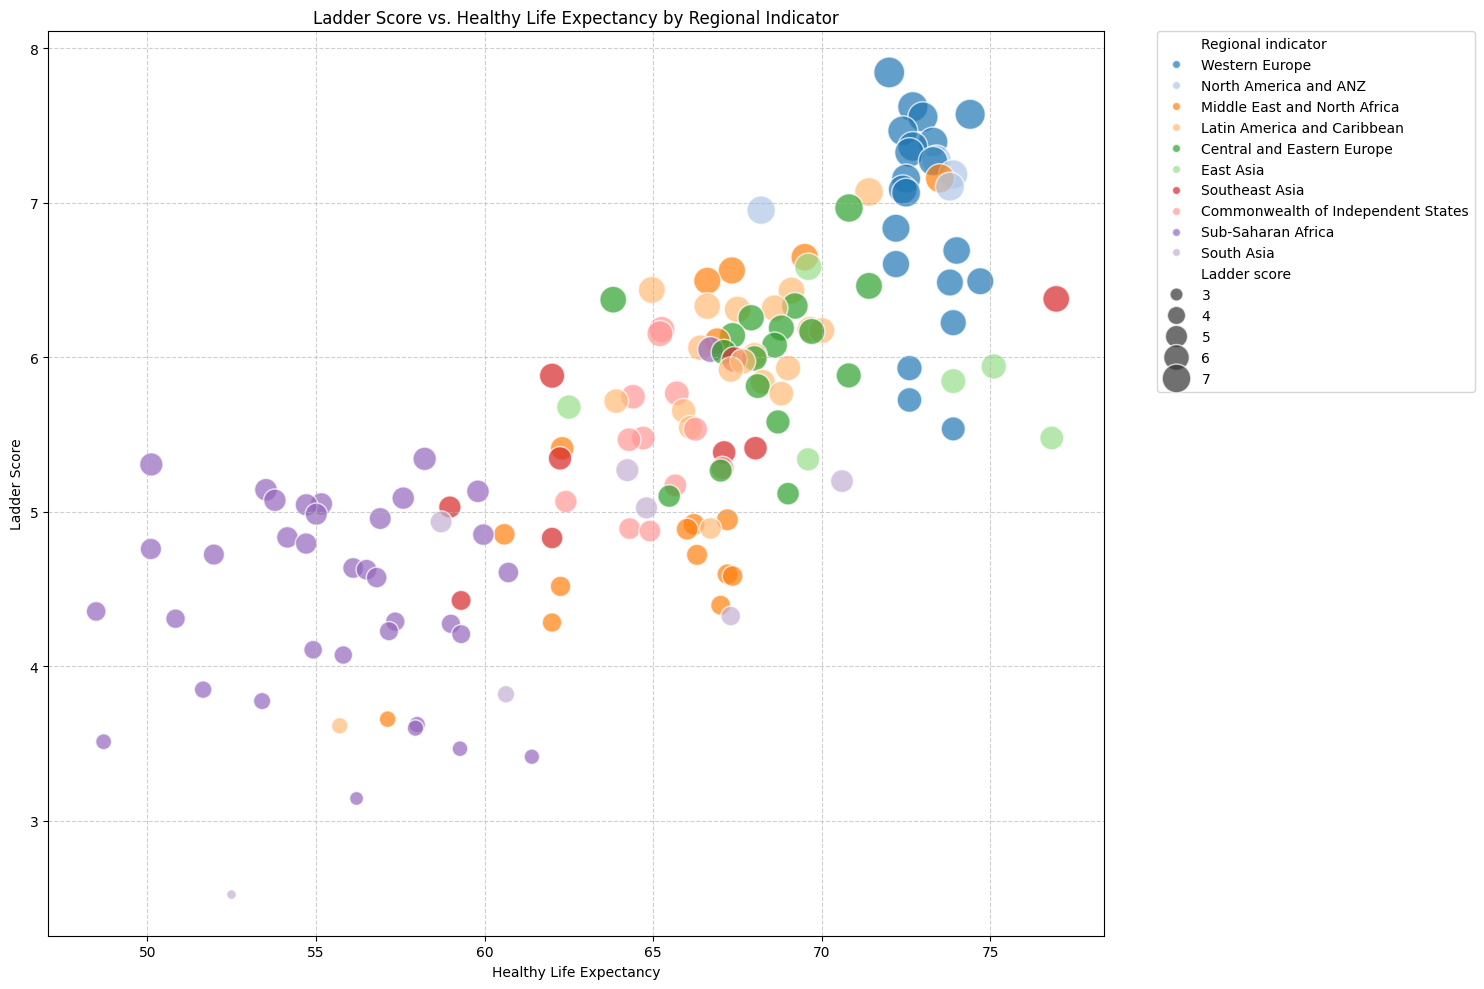

In [24]:
plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df,
    x='Healthy life expectancy',
    y='Ladder score',
    hue='Regional indicator',
    size='Ladder score',
    sizes=(50, 500),
    alpha=0.7,
    palette='tab20'
)
plt.title('Ladder Score vs. Healthy Life Expectancy by Regional Indicator')
plt.xlabel('Healthy Life Expectancy')
plt.ylabel('Ladder Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Key Storytelling Insights: GDP, Health, and Happiness

From our visualizations comparing 'Ladder score' with 'Logged GDP per capita' and 'Healthy life expectancy', a compelling story emerges about the drivers of global happiness:

1.  **Economic Prosperity (GDP) and Happiness are Linked**: There is a clear positive correlation between a nation's economic output per person (Logged GDP per capita) and its citizens' overall happiness (Ladder score). Wealthier countries tend to report higher happiness levels.

2.  **Healthy Lives Lead to Happier Lives**: Similarly, a strong positive relationship exists between 'Healthy life expectancy' and 'Ladder score'. Countries where people live longer, healthier lives are generally happier. This highlights the fundamental role of health and well-being in perceived happiness.

3.  **Regional Patterns are Crucial**: Both economic prosperity and healthy life expectancy exhibit strong regional clustering. For instance:
    *   **Western Europe and North America & ANZ** consistently appear in the upper-right quadrant of both plots, indicating high GDP, high healthy life expectancy, and high happiness scores.
    *   **Sub-Saharan Africa** generally occupies the lower-left, showing lower scores across all three indicators.
    *   Other regions, such as **East Asia** or **Latin America and Caribbean**, fall into a middle ground, with varying degrees of prosperity, health, and happiness.

In essence, the data suggests that while economic strength and good health are significant predictors of happiness, these factors are not uniformly distributed globally. Regional contexts play a vital role in shaping these relationships, creating a diverse landscape of well-being across the world.

### Happiness vs. Freedom to Make Life Choices by Region
Now, let's explore the relationship between 'Ladder score' and 'Freedom to make life choices', again differentiated by 'Regional indicator'. This can highlight how personal liberties contribute to overall happiness across different global regions.

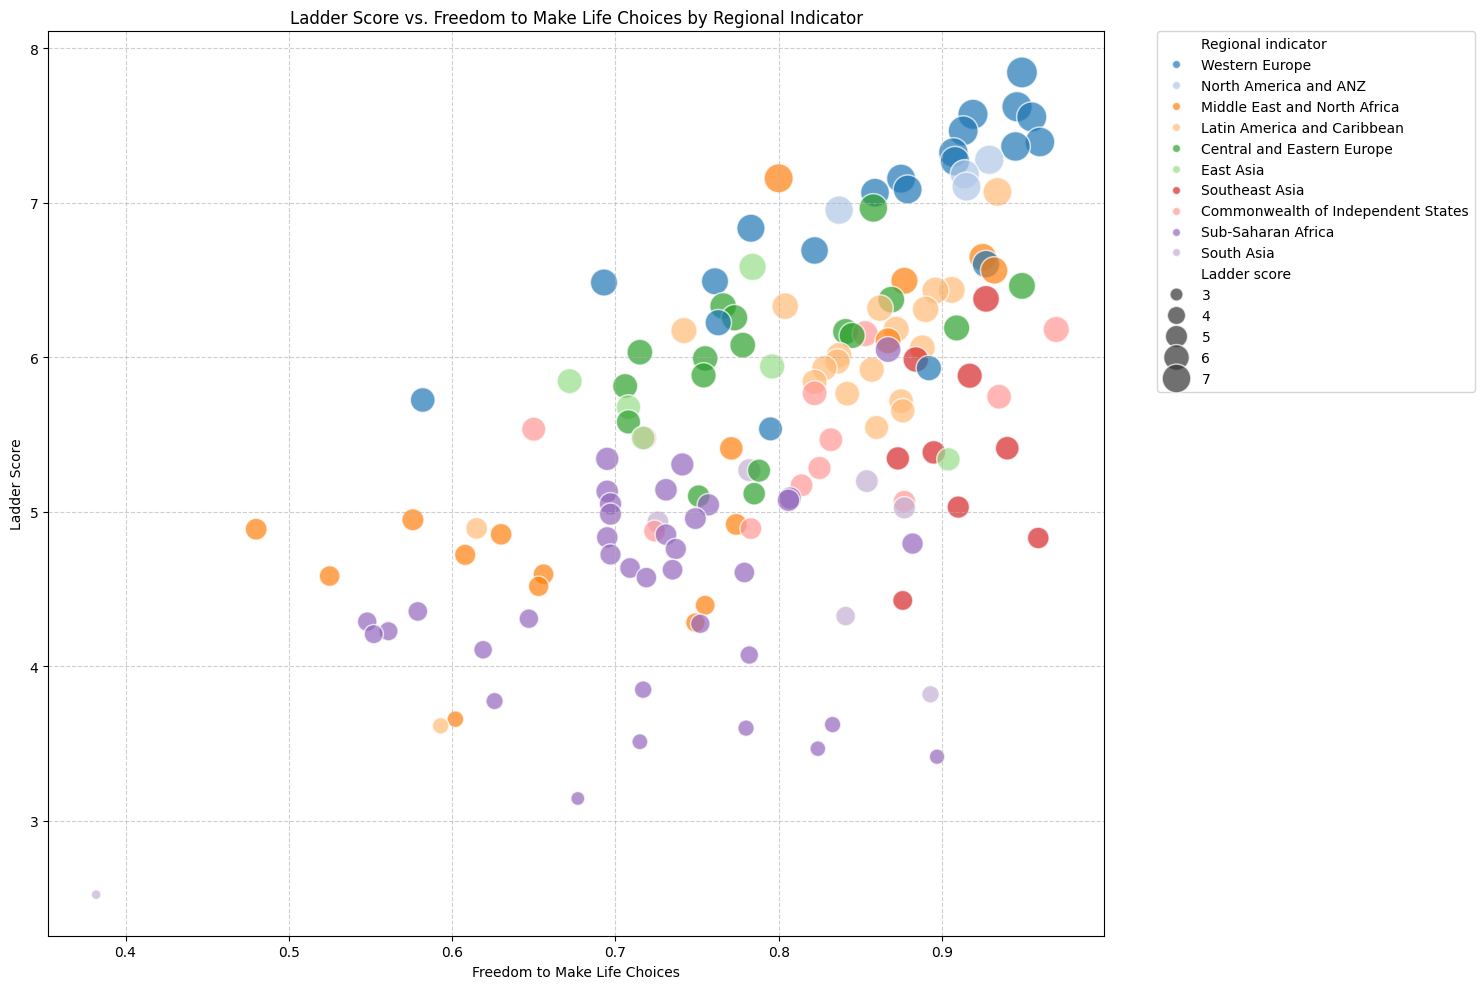

In [25]:
plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df,
    x='Freedom to make life choices',
    y='Ladder score',
    hue='Regional indicator',
    size='Ladder score',
    sizes=(50, 500),
    alpha=0.7,
    palette='tab20'
)
plt.title('Ladder Score vs. Freedom to Make Life Choices by Regional Indicator')
plt.xlabel('Freedom to Make Life Choices')
plt.ylabel('Ladder Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Happiness vs. Perceptions of Corruption by Region
Finally, let's examine the relationship between 'Ladder score' and 'Perceptions of corruption', categorized by 'Regional indicator'. This can illustrate how trust in institutions and lack of corruption might influence a country's happiness levels.

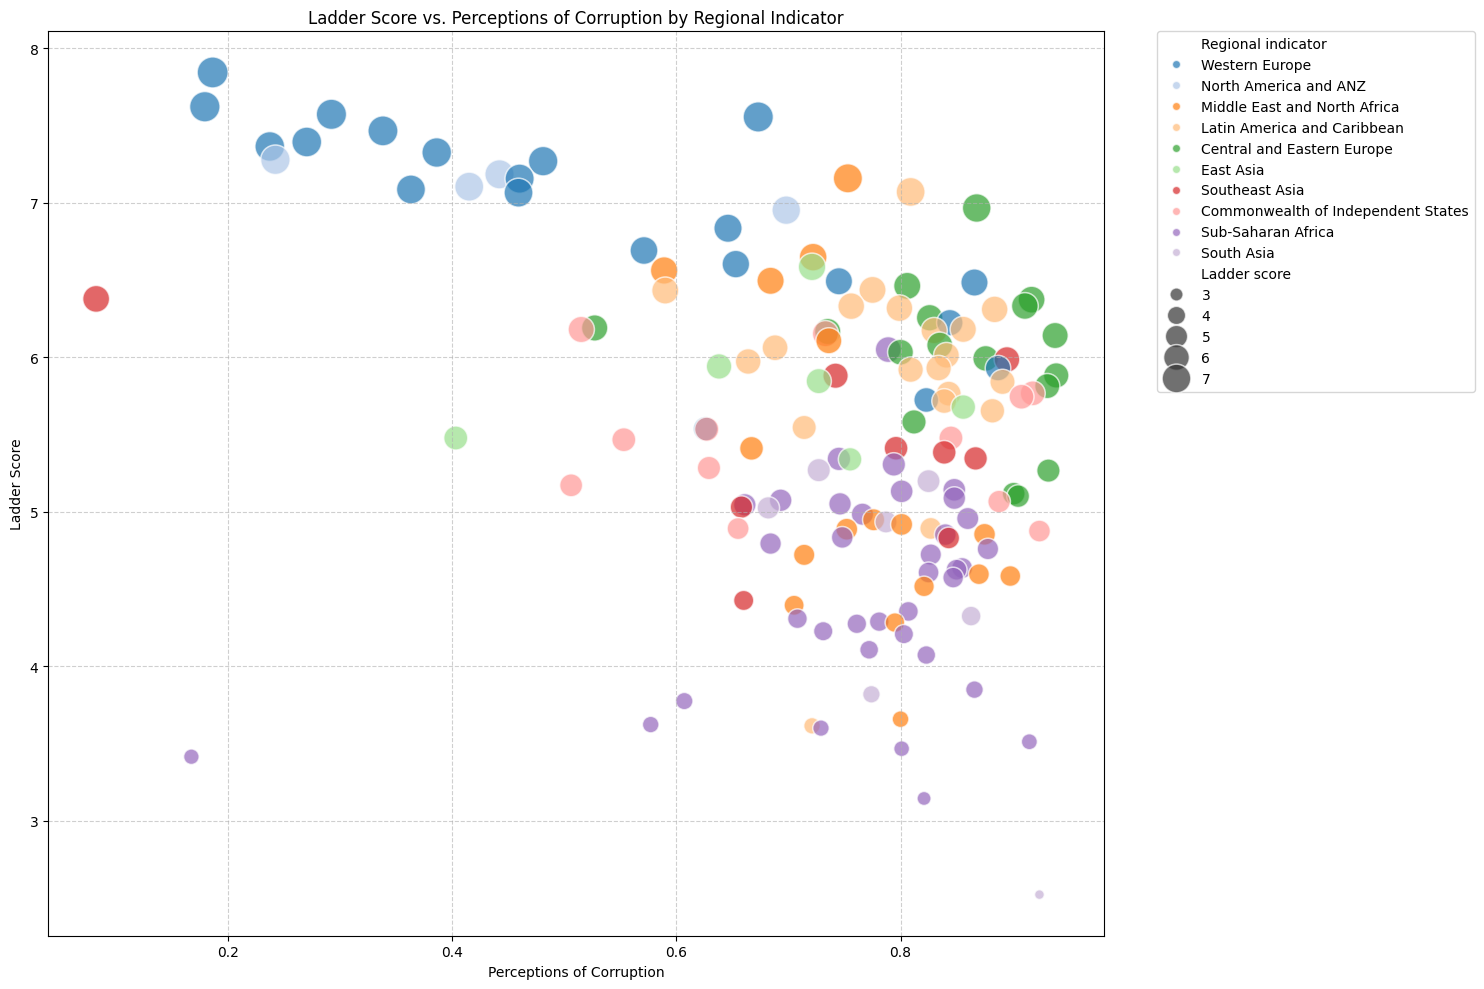

In [26]:
plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df,
    x='Perceptions of corruption',
    y='Ladder score',
    hue='Regional indicator',
    size='Ladder score',
    sizes=(50, 500),
    alpha=0.7,
    palette='tab20'
)
plt.title('Ladder Score vs. Perceptions of Corruption by Regional Indicator')
plt.xlabel('Perceptions of Corruption')
plt.ylabel('Ladder Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Comprehensive Storytelling: Drivers of Global Happiness

Our journey through the World Happiness Report 2021 dataset has revealed several compelling insights into the factors that influence a nation's 'Ladder score' (happiness). Here's a consolidated story:

1.  **Economic Prosperity (GDP) is a Foundation**: There's a clear and strong positive correlation between a country's `Logged GDP per capita` and its `Ladder score`. Wealthier nations generally report higher happiness. This suggests that economic stability and resources provide a fundamental base for well-being.

2.  **Healthy Lives Lead to Happier Lives**: Similarly, `Healthy life expectancy` is highly correlated with happiness. Societies where people live longer, healthier lives are consistently among the happiest. This underscores the critical role of public health and access to quality healthcare in overall life satisfaction.

3.  **Freedom Fuels Happiness**: The `Freedom to make life choices` also plays a significant role. Countries with higher perceived freedom tend to exhibit higher `Ladder scores`. This indicates that personal autonomy, the ability to control one's destiny, and democratic freedoms are vital for psychological well-being.

4.  **Low Corruption, High Happiness**: A robust inverse relationship exists with `Perceptions of corruption`. As perceived corruption decreases, happiness tends to increase. This highlights the importance of good governance, trust in institutions, and a fair society for fostering contentment among citizens.

5.  **Regional Context Matters Immensely**: Throughout our analysis, `Regional indicator` has proven to be a crucial differentiating factor. Regions like **Western Europe** and **North America and ANZ** consistently rank high across all positive indicators (GDP, health, freedom) and low on corruption, leading to high happiness scores. Conversely, regions like **Sub-Saharan Africa** often face challenges across these same metrics, reflected in lower happiness scores.

**Overall Narrative**: Global happiness is a complex tapestry woven from various threads. While economic prosperity and good health provide a strong foundation, the presence of personal freedoms and low levels of corruption are equally critical in fostering a thriving and happy society. These factors are not isolated but interact within diverse regional contexts, painting a rich picture of well-being around the world.